## 1. Učitavanje biblioteka i podataka


In [2]:

import re
import ssl
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer, word_tokenize

try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass
#ako su potrebne instalacije 
#nltk.download("stopwords")
#nltk.download("wordnet")


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD


from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


import joblib

In [3]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
data["Score"].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

In [5]:
data_small, _ = train_test_split(
    data,
    train_size=100000,
    stratify=data["Score"],
    random_state=42
)
data_small["Score"].value_counts()

Score
5    63879
4    14188
1     9195
3     7501
2     5237
Name: count, dtype: int64

In [6]:
data_small.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               5
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   3
Text                      0
dtype: int64

In [7]:
data_small["TextFull"] = data_small["Summary"].fillna("") + " " + data_small["Text"].fillna("")


In [8]:
data_small.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,TextFull
301152,301153,B003Z6ZGZK,A3LN5V0RGOCTYY,Jim Brown,0,0,5,1347062400,Simplified,I can have a great cup of coffee whenever I fe...,Simplified I can have a great cup of coffee wh...
81192,81193,B0070PV73M,A2NVA94G5T50TA,Thomas F. Lonergan,0,0,5,1318636800,Excellent treat for training and walks,This is a favorite of Boxer and Rottie. It ha...,Excellent treat for training and walks This is...
122872,122873,B000FDMLV8,AZWR5854QIU2X,Mullough,0,0,5,1226275200,Delicious and easy,I enjoy the smell of fresh bread baking and us...,Delicious and easy I enjoy the smell of fresh ...
268999,269000,B004SRFYMK,A37XC5PH84JEO,"LucianaMachadoMKimonos ""LucianaMachadoSimon""",1,1,5,1340323200,As good as the other ones that I also gave 5 s...,"Zico is very good, but not better than the oth...",As good as the other ones that I also gave 5 s...
377424,377425,B001AML2LI,A9EHCOGPUJ0UH,M. Miller,4,4,5,1196899200,100 Calories Never Tasted So Good,Yummy! So great! If you enjoy mint and chocola...,100 Calories Never Tasted So Good Yummy! So gr...


In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

data_small["cleaned_full"] = data_small["TextFull"].apply(clean_text)

In [10]:
final_data = data_small[["cleaned_full","Score"]]

In [11]:
final_data.head()


,cleaned_full,Score
301152,simplified great cup coffee whenever feel like...,5
81192,excellent treat training walk favorite boxer r...,5
122872,delicious easy enjoy smell fresh bread baking ...,5
268999,good one also gave star zico good better one g...,5
377424,calorie never tasted good yummy great enjoy mi...,5


In [12]:
X = final_data["cleaned_full"]
y = final_data["Score"]

X_full_train, X_full_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
models = {
    "LinearSVC": LinearSVC(dual="auto", max_iter=5000),
    "SGD hinge": SGDClassifier(loss="hinge", random_state=42),
    "LogReg": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random forest": RandomForestClassifier(n_estimators=300,max_depth=30,max_features="sqrt",min_samples_split=5,n_jobs=-1,
    random_state=42),
    "ComplementNB": ComplementNB(),
}

tfidf_settings = {
    "TFIDF_10k": dict(max_features=10000, ngram_range=(1,2), min_df=2),
    "TFIDF_20k": dict(max_features=20000, ngram_range=(1,2), min_df=2),
}

def run_block(Xtr, Xte, ytr, yte, label):
    rows = []
    for tfidf_name, tfidf_kwargs in tfidf_settings.items():
        for model_name, model in models.items():

            

            print(f"Treniram: {label} | {tfidf_name} | {model_name} ...")

            pipe = Pipeline([
                ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
                ("clf", model)
            ])

            pipe.fit(Xtr, ytr)
            pred = pipe.predict(Xte)

            acc = accuracy_score(yte, pred)
            f1m = f1_score(yte, pred, average="macro")
            f1w = f1_score(yte, pred, average="weighted")

            print(f"  -> done | acc={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f}")

            rows.append({
                "Dataset": label,          
                "TFIDF": tfidf_name,
                "Model": model_name,
                "Accuracy": acc,
                "F1_macro": f1m,
                "F1_weighted": f1w,
            })
    return rows

In [14]:
train_df = pd.DataFrame({
    "cleaned_full": X_full_train,
    "Score": y_train
})

min_count = train_df["Score"].value_counts().min()

train_bal = (
    train_df.groupby("Score", group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .sample(frac=1, random_state=42)
)

X_full_train_bal = train_bal["cleaned_full"]
y_train_bal = train_bal["Score"]

In [15]:
rows = []
rows += run_block(X_full_train,     X_full_test, y_train,     y_test, "RAW")
rows += run_block(X_full_train_bal, X_full_test, y_train_bal, y_test, "BAL")

results_df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df

Treniram: RAW | TFIDF_10k | LinearSVC ...
  -> done | acc=0.7506 | f1_macro=0.5347 | f1_weighted=0.7256
Treniram: RAW | TFIDF_10k | SGD hinge ...
  -> done | acc=0.7151 | f1_macro=0.3896 | f1_weighted=0.6379
Treniram: RAW | TFIDF_10k | LogReg ...
  -> done | acc=0.7484 | f1_macro=0.5176 | f1_weighted=0.7162
Treniram: RAW | TFIDF_10k | Random forest ...
  -> done | acc=0.6531 | f1_macro=0.2156 | f1_weighted=0.5289
Treniram: RAW | TFIDF_10k | ComplementNB ...
  -> done | acc=0.6897 | f1_macro=0.4539 | f1_weighted=0.6812
Treniram: RAW | TFIDF_20k | LinearSVC ...
  -> done | acc=0.7548 | f1_macro=0.5560 | f1_weighted=0.7342
Treniram: RAW | TFIDF_20k | SGD hinge ...
  -> done | acc=0.7156 | f1_macro=0.3908 | f1_weighted=0.6377
Treniram: RAW | TFIDF_20k | LogReg ...
  -> done | acc=0.7523 | f1_macro=0.5255 | f1_weighted=0.7198
Treniram: RAW | TFIDF_20k | Random forest ...
  -> done | acc=0.6469 | f1_macro=0.1910 | f1_weighted=0.5159
Treniram: RAW | TFIDF_20k | ComplementNB ...
  -> done | ac

,Dataset,TFIDF,Model,Accuracy,F1_macro,F1_weighted
5,RAW,TFIDF_20k,LinearSVC,0.75480,0.556026,0.734203
0,RAW,TFIDF_10k,LinearSVC,0.75060,0.534741,0.725585
7,RAW,TFIDF_20k,LogReg,0.75230,0.525474,0.719756
16,BAL,TFIDF_20k,SGD hinge,0.68625,0.520687,0.695926
2,RAW,TFIDF_10k,LogReg,0.74845,0.517581,0.716191
11,BAL,TFIDF_10k,SGD hinge,0.67950,0.513201,0.690188
17,BAL,TFIDF_20k,LogReg,0.63475,0.513080,0.663181
12,BAL,TFIDF_10k,LogReg,0.63020,0.508750,0.659192
18,BAL,TFIDF_20k,Random forest,0.65925,0.505050,0.673027
13,BAL,TFIDF_10k,Random forest,0.65325,0.501133,0.669124


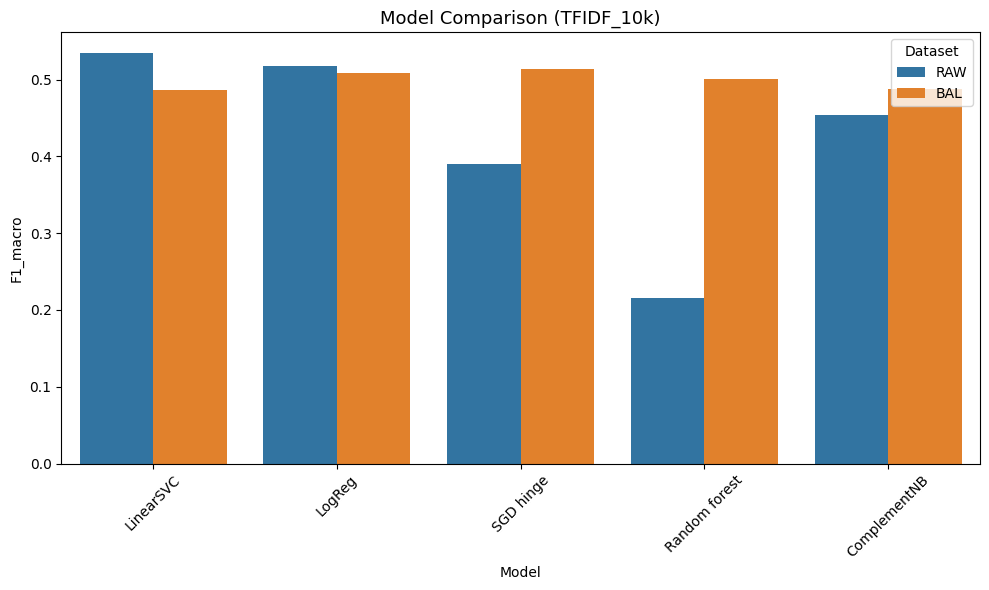

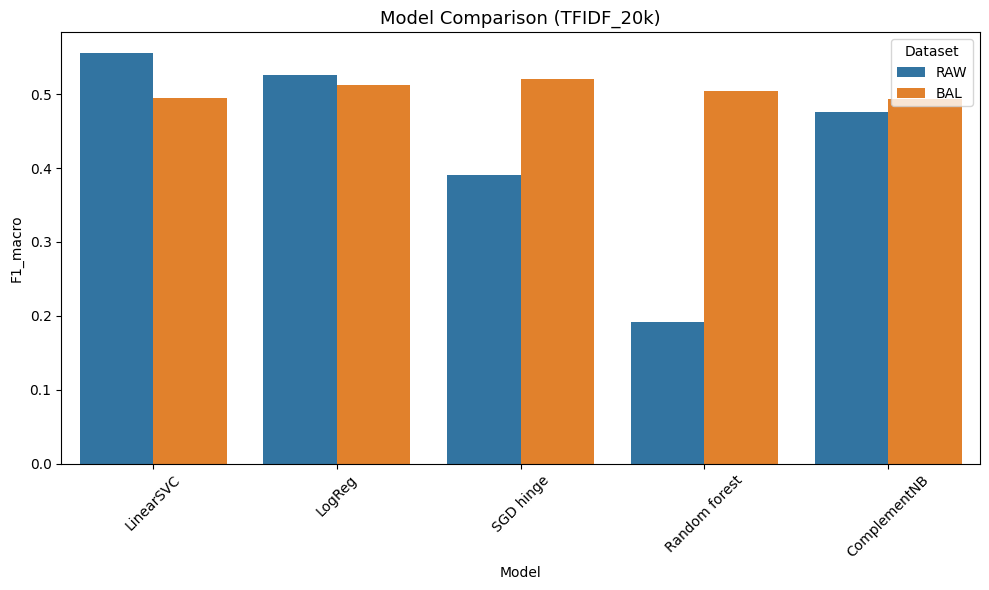

In [16]:
for tfidf_name in ["TFIDF_10k", "TFIDF_20k"]:
    plt.figure(figsize=(10,6))
    
    sub = results_df[results_df["TFIDF"] == tfidf_name]
    
    sns.barplot(
        data=sub,
        x="Model",
        y="F1_macro",
        hue="Dataset",
    )
    
    plt.xticks(rotation=45)
    plt.title(f"Model Comparison ({tfidf_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [17]:
def show_cm_raw_vs_bal_for_model(
    model_name,
    tfidf_name,
    X_train, y_train,
    X_train_bal, y_train_bal,
    X_test, y_test,
    title_prefix="SCORE",
    normalize="true"
):
    print("="*90)
    print(f"{title_prefix} | Model: {model_name} | {tfidf_name}")
    print("="*90)

    tfidf_kwargs = tfidf_settings[tfidf_name]

    pipe_raw = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
        ("clf", models[model_name])
    ])
    pipe_raw.fit(X_train, y_train)

    pred_raw_tr = pipe_raw.predict(X_train)
    pred_raw_te = pipe_raw.predict(X_test)

    cm_raw_tr = confusion_matrix(y_train, pred_raw_tr, normalize=normalize)
    cm_raw_te = confusion_matrix(y_test, pred_raw_te, normalize=normalize)

    pipe_bal = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
        ("clf", models[model_name])
    ])
    pipe_bal.fit(X_train_bal, y_train_bal)

    pred_bal_tr = pipe_bal.predict(X_train_bal)
    pred_bal_te = pipe_bal.predict(X_test)

    cm_bal_tr = confusion_matrix(y_train_bal, pred_bal_tr, normalize=normalize)
    cm_bal_te = confusion_matrix(y_test, pred_bal_te, normalize=normalize)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ConfusionMatrixDisplay(cm_raw_tr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
    axes[0,0].set_title("RAW | TRAIN")
    axes[0,0].grid(False)

    ConfusionMatrixDisplay(cm_raw_te).plot(ax=axes[0,1], cmap="Blues", colorbar=False)
    axes[0,1].set_title("RAW | TEST")
    axes[0,1].grid(False)

    ConfusionMatrixDisplay(cm_bal_tr).plot(ax=axes[1,0], cmap="Blues", colorbar=False)
    axes[1,0].set_title("BAL | TRAIN")
    axes[1,0].grid(False)

    ConfusionMatrixDisplay(cm_bal_te).plot(ax=axes[1,1], cmap="Blues", colorbar=False)
    axes[1,1].set_title("BAL | TEST")
    axes[1,1].grid(False)

    plt.suptitle(f"{title_prefix}: {model_name} | {tfidf_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n--- RAW | TRAIN report ---")
    print(classification_report(y_train, pred_raw_tr))

    print("\n--- RAW | TEST report ---")
    print(classification_report(y_test, pred_raw_te))

    print("\n--- BAL | TRAIN report ---")
    print(classification_report(y_train_bal, pred_bal_tr))

    print("\n--- BAL | TEST report ---")
    print(classification_report(y_test, pred_bal_te))

SCORE | Model: LinearSVC | TFIDF_20k


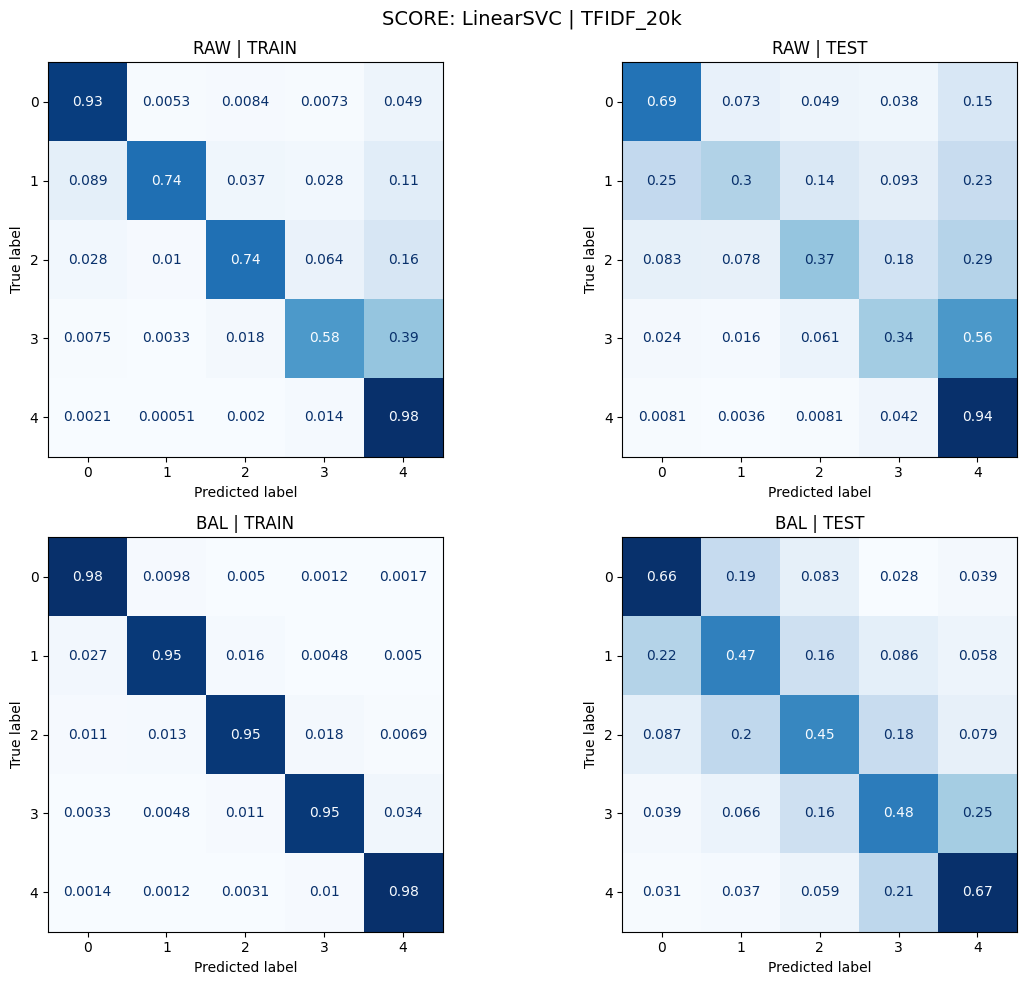


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.90      0.93      0.92      7356
           2       0.95      0.74      0.83      4190
           3       0.89      0.74      0.81      6001
           4       0.84      0.58      0.69     11350
           5       0.89      0.98      0.93     51103

    accuracy                           0.89     80000
   macro avg       0.90      0.79      0.84     80000
weighted avg       0.89      0.89      0.88     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.70      0.69      0.70      1839
           2       0.48      0.30      0.37      1047
           3       0.52      0.37      0.44      1500
           4       0.50      0.34      0.40      2838
           5       0.83      0.94      0.88     12776

    accuracy                           0.75     20000
   macro avg       0.60      0.53      0.56     20000
weighted avg       0.7

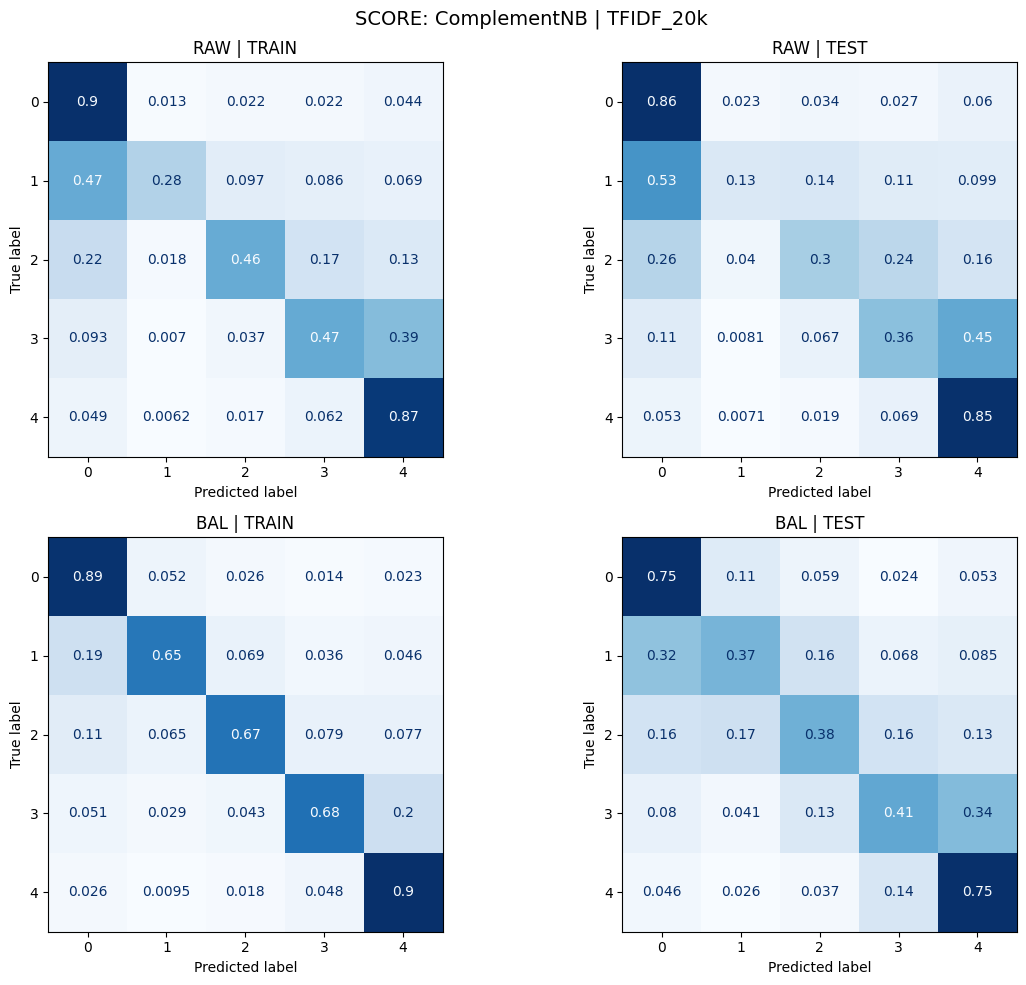


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.49      0.90      0.64      7356
           2       0.66      0.28      0.40      4190
           3       0.60      0.46      0.52      6001
           4       0.53      0.47      0.50     11350
           5       0.88      0.87      0.87     51103

    accuracy                           0.75     80000
   macro avg       0.63      0.60      0.59     80000
weighted avg       0.76      0.75      0.75     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.45      0.86      0.59      1839
           2       0.38      0.13      0.19      1047
           3       0.41      0.30      0.35      1500
           4       0.42      0.36      0.39      2838
           5       0.86      0.85      0.86     12776

    accuracy                           0.70     20000
   macro avg       0.51      0.50      0.48     20000
weighted avg       0.7

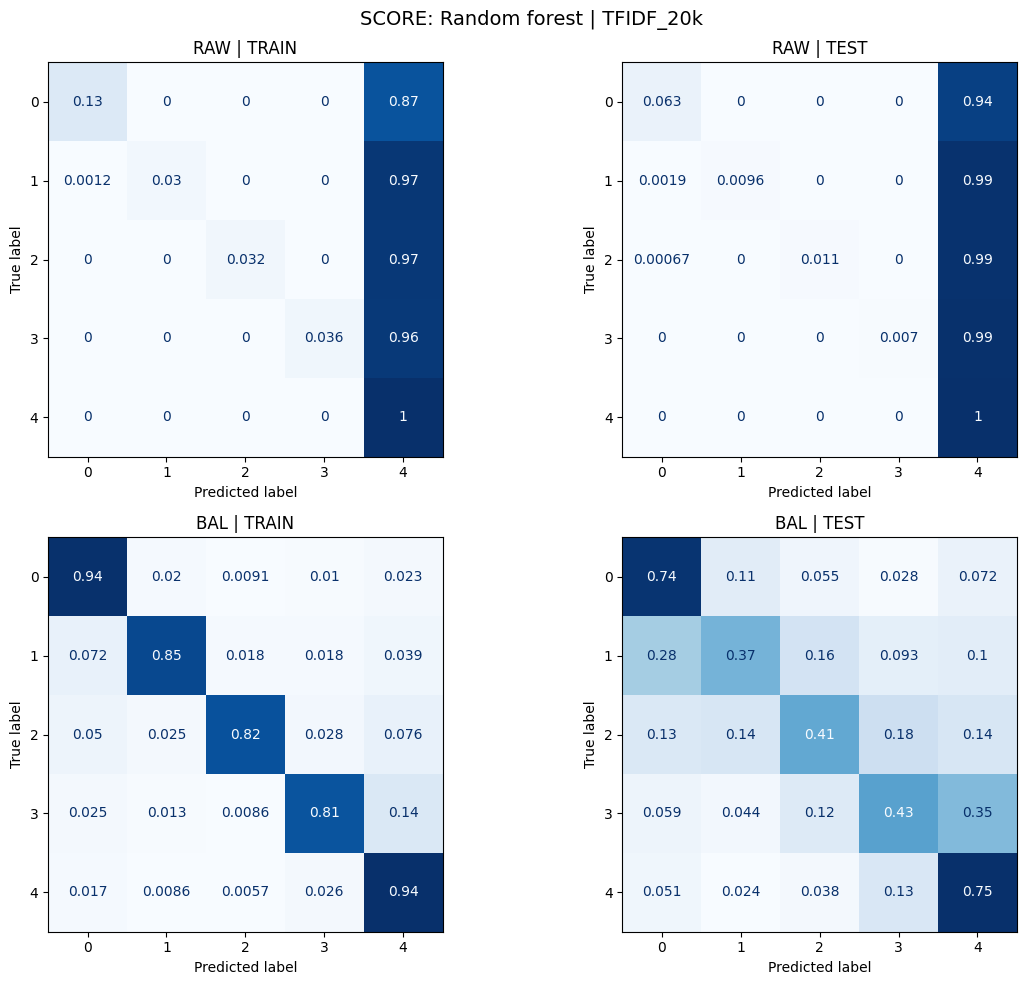


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.99      0.13      0.24      7356
           2       1.00      0.03      0.06      4190
           3       1.00      0.03      0.06      6001
           4       1.00      0.04      0.07     11350
           5       0.65      1.00      0.79     51103

    accuracy                           0.66     80000
   macro avg       0.93      0.25      0.24     80000
weighted avg       0.78      0.66      0.54     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.97      0.06      0.12      1839
           2       1.00      0.01      0.02      1047
           3       1.00      0.01      0.02      1500
           4       1.00      0.01      0.01      2838
           5       0.64      1.00      0.78     12776

    accuracy                           0.65     20000
   macro avg       0.92      0.22      0.19     20000
weighted avg       0.7

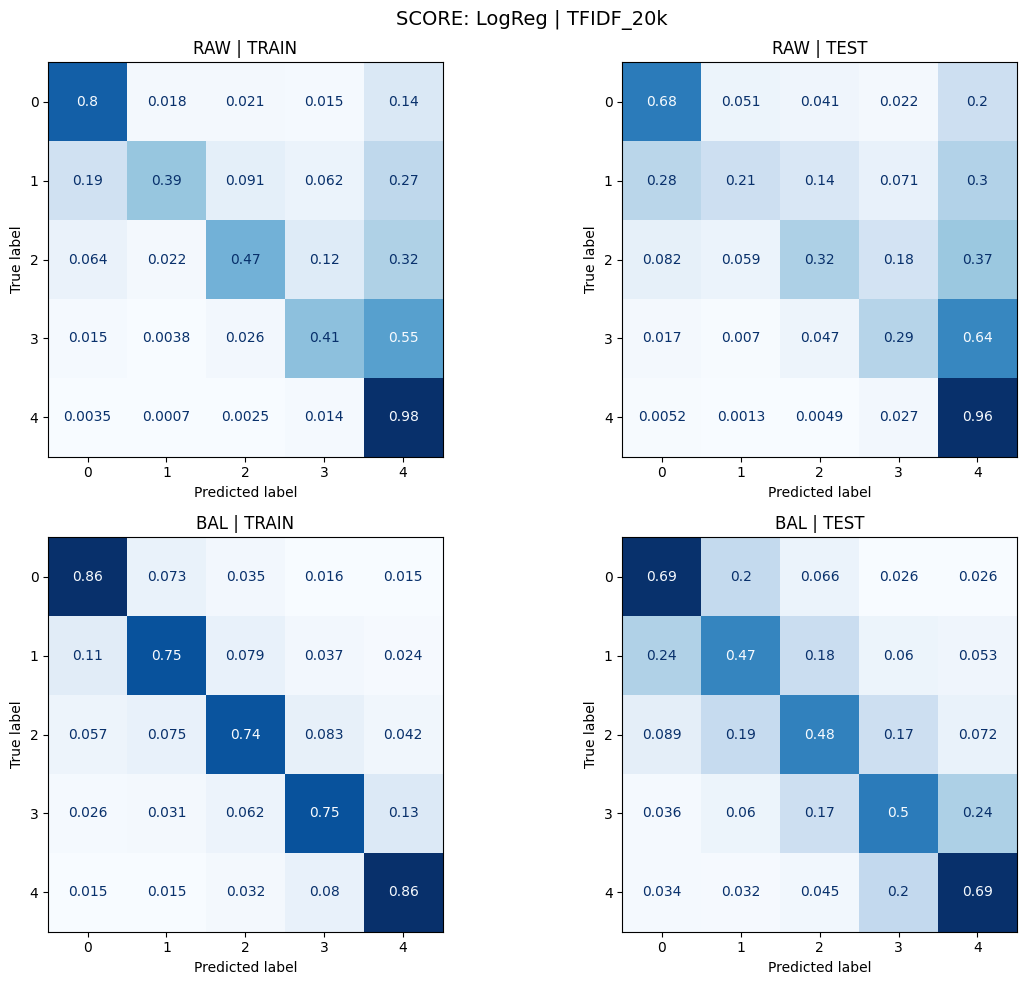


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.79      0.80      0.80      7356
           2       0.83      0.39      0.53      4190
           3       0.75      0.47      0.58      6001
           4       0.72      0.41      0.52     11350
           5       0.83      0.98      0.90     51103

    accuracy                           0.81     80000
   macro avg       0.78      0.61      0.66     80000
weighted avg       0.80      0.81      0.79     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.70      0.68      0.69      1839
           2       0.50      0.21      0.29      1047
           3       0.53      0.32      0.39      1500
           4       0.53      0.29      0.37      2838
           5       0.80      0.96      0.87     12776

    accuracy                           0.75     20000
   macro avg       0.61      0.49      0.53     20000
weighted avg       0.7

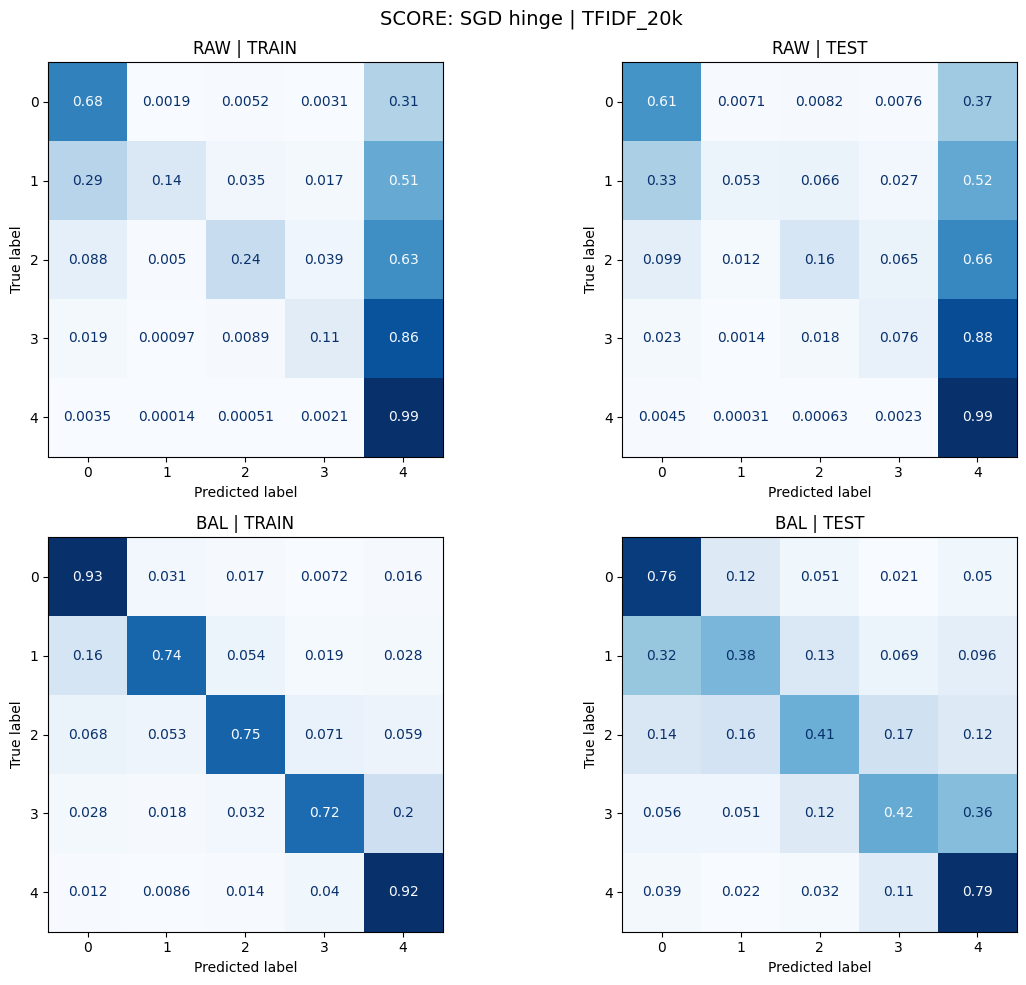


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           1       0.70      0.68      0.69      7356
           2       0.91      0.14      0.25      4190
           3       0.82      0.24      0.37      6001
           4       0.74      0.11      0.19     11350
           5       0.74      0.99      0.85     51103

    accuracy                           0.74     80000
   macro avg       0.78      0.43      0.47     80000
weighted avg       0.75      0.74      0.67     80000


--- RAW | TEST report ---
              precision    recall  f1-score   support

           1       0.64      0.61      0.63      1839
           2       0.59      0.05      0.10      1047
           3       0.63      0.16      0.26      1500
           4       0.56      0.08      0.13      2838
           5       0.73      0.99      0.84     12776

    accuracy                           0.72     20000
   macro avg       0.63      0.38      0.39     20000
weighted avg       0.6

In [18]:
chosen_models = ["LinearSVC", "ComplementNB", "Random forest","LogReg","SGD hinge"]

for m in chosen_models:
    show_cm_raw_vs_bal_for_model(
        model_name=m,
        tfidf_name="TFIDF_20k",   # ili "TFIDF_10k"
        X_train=X_full_train, y_train=y_train,
        X_train_bal=X_full_train_bal, y_train_bal=y_train_bal,
        X_test=X_full_test, y_test=y_test,
        title_prefix="SCORE"
    )

In [19]:
NB_MODELS = ( ComplementNB)

def run_tfidf20k_svd_only(Xtr, Xte, ytr, yte, k=300, label="RAW"):
    rows = []
    tfidf_kwargs = tfidf_settings["TFIDF_10k"]

    print("="*60)
    print(f"EKSPERIMENT | Dataset: {label} | TFIDF_10k + SVD({k})")
    print("="*60)

    for model_name, model in models.items():

        # NB preskacemo jer SVD moze dati negativne vrednosti
        if isinstance(model, NB_MODELS):
            print(f"Preskacem {model_name} + SVD (negativne vrednosti)")
            continue

        rep = f"TFIDF_10k+SVD({k})"
        steps = [
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("svd", TruncatedSVD(n_components=k, random_state=42)),
            ("clf", model),
        ]
        pipe = Pipeline(steps)

        print(f"\nTreniram: {model_name} | {rep}")
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)

        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")
        f1w = f1_score(yte, pred, average="weighted")

        evr_sum = float(pipe.named_steps["svd"].explained_variance_ratio_.sum())
        print(f"    SVD explained variance sum = {evr_sum:.4f}")
        print(f"    Done | Acc={acc:.4f} | F1_macro={f1m:.4f} | F1_weighted={f1w:.4f}")

        rows.append({
            "Dataset": label,
            "Rep": rep,
            "Model": model_name,
            "Accuracy": acc,
            "F1_macro": f1m,
            "F1_weighted": f1w,
            "SVD_explained_var_sum": evr_sum
        })

    print("\nEksperiment zavrsen.\n")
    return pd.DataFrame(rows).sort_values("F1_macro", ascending=False)

In [20]:
df_example = run_tfidf20k_svd_only(
    X_full_train,
    X_full_test,
    y_train,
    y_test,
    k=300,
    label="RAW"
)

df_example

EKSPERIMENT | Dataset: RAW | TFIDF_10k + SVD(300)

Treniram: LinearSVC | TFIDF_10k+SVD(300)
    SVD explained variance sum = 0.3130
    Done | Acc=0.7088 | F1_macro=0.3844 | F1_weighted=0.6450

Treniram: SGD hinge | TFIDF_10k+SVD(300)
    SVD explained variance sum = 0.3130
    Done | Acc=0.6884 | F1_macro=0.3276 | F1_weighted=0.6005

Treniram: LogReg | TFIDF_10k+SVD(300)
    SVD explained variance sum = 0.3130
    Done | Acc=0.7152 | F1_macro=0.4275 | F1_weighted=0.6644

Treniram: Random forest | TFIDF_10k+SVD(300)
    SVD explained variance sum = 0.3130
    Done | Acc=0.7156 | F1_macro=0.4368 | F1_weighted=0.6485
Preskacem ComplementNB + SVD (negativne vrednosti)

Eksperiment zavrsen.



,Dataset,Rep,Model,Accuracy,F1_macro,F1_weighted,SVD_explained_var_sum
3,RAW,TFIDF_10k+SVD(300),Random forest,0.71555,0.436815,0.648484,0.312985
2,RAW,TFIDF_10k+SVD(300),LogReg,0.71520,0.427492,0.664367,0.312985
0,RAW,TFIDF_10k+SVD(300),LinearSVC,0.70880,0.384417,0.644970,0.312985
1,RAW,TFIDF_10k+SVD(300),SGD hinge,0.68840,0.327619,0.600508,0.312985


In [21]:
def show_cm_tfidf_svd(
    model_name,
    X_train, y_train,
    X_test, y_test,
    k=300,
    tfidf_name="TFIDF_10k",
    title_prefix="SCORE",
    normalize="true"
):
    if isinstance(models[model_name], NB_MODELS):
        print(f"Preskacem {model_name} + SVD (negativne vrednosti)")
        return

    tfidf_kwargs = tfidf_settings[tfidf_name]

    print("="*80)
    print(f"{title_prefix} | {model_name} | {tfidf_name} + SVD({k})")
    print("="*80)

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
        ("svd", TruncatedSVD(n_components=k, random_state=42)),
        ("clf", models[model_name])
    ])

    pipe.fit(X_train, y_train)

    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    cm_tr = confusion_matrix(y_train, pred_tr, normalize=normalize)
    cm_te = confusion_matrix(y_test, pred_te, normalize=normalize)

    # ===== PLOT =====
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    ConfusionMatrixDisplay(cm_tr).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title("TRAIN")
    axes[0].grid(False)

    ConfusionMatrixDisplay(cm_te).plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("TEST")
    axes[1].grid(False)

    plt.suptitle(f"{model_name} | {tfidf_name} + SVD({k})", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("\n--- TRAIN report ---")
    print(classification_report(y_train, pred_tr))

    print("\n--- TEST report ---")
    print(classification_report(y_test, pred_te))

Najbolji SVD model: Random forest
SCORE | Random forest | TFIDF_10k + SVD(300)


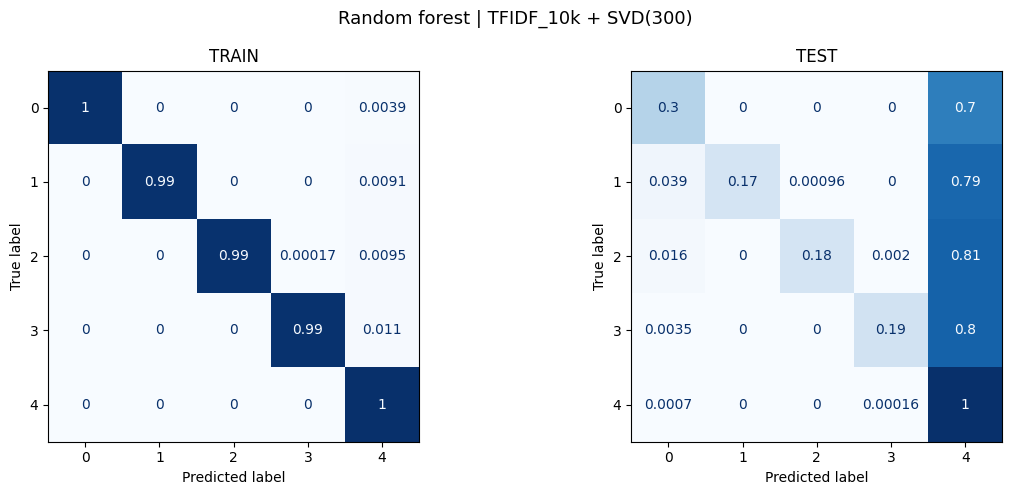


--- TRAIN report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      7356
           2       1.00      0.99      1.00      4190
           3       1.00      0.99      1.00      6001
           4       1.00      0.99      0.99     11350
           5       1.00      1.00      1.00     51103

    accuracy                           1.00     80000
   macro avg       1.00      0.99      1.00     80000
weighted avg       1.00      1.00      1.00     80000


--- TEST report ---
              precision    recall  f1-score   support

           1       0.87      0.30      0.45      1839
           2       1.00      0.17      0.29      1047
           3       1.00      0.18      0.30      1500
           4       0.99      0.19      0.32      2838
           5       0.70      1.00      0.82     12776

    accuracy                           0.72     20000
   macro avg       0.91      0.37      0.44     20000
weighted avg       0.79      0.72 

In [22]:

best_model = df_example.iloc[0]["Model"]
print("Najbolji SVD model:", best_model)

show_cm_tfidf_svd(
    model_name=best_model,
    X_train=X_full_train,
    y_train=y_train,
    X_test=X_full_test,
    y_test=y_test,
    k=300
)

  -> done | k=100.0000
  -> done | k=300.0000
  -> done | k=500.0000


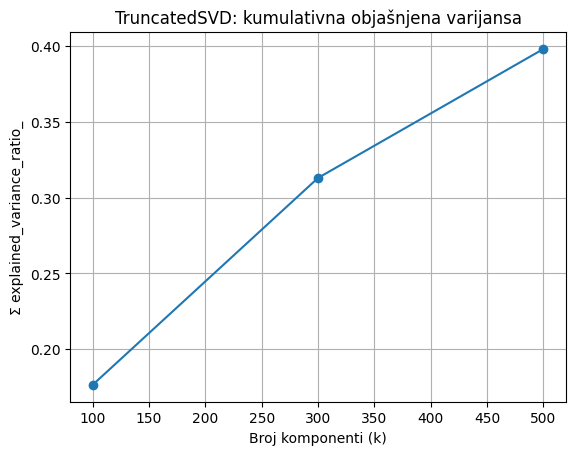

In [23]:

def plot_svd_variance(Xtr, tfidf_kwargs, ks=(100,300,500)):
    tfidf = TfidfVectorizer(**tfidf_kwargs)
    X = tfidf.fit_transform(Xtr)

    sums = []
    for k in ks:
        svd = TruncatedSVD(n_components=k, random_state=42)
        svd.fit(X)
        sums.append(svd.explained_variance_ratio_.sum())
        print(f"  -> done | k={k:.4f}")

    plt.figure()
    plt.plot(list(ks), sums, marker="o")
    plt.title("TruncatedSVD: kumulativna objašnjena varijansa")
    plt.xlabel("Broj komponenti (k)")
    plt.ylabel("Σ explained_variance_ratio_")
    plt.grid(True)
    plt.show()

plot_svd_variance(X_full_train, tfidf_settings["TFIDF_10k"], ks=(100,300,500))
